In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

df = pd.read_csv("train_v2.csv", nrows=50000)


In [15]:
json_columns = ['device','geoNetwork','totals','trafficSource']

for column in json_columns:
    df[column] = df[column].apply(json.loads)
    column_df = pd.json_normalize(df[column])
    column_df.columns = [f"{column}.{subcolumn}" for subcolumn in column_df.columns]
    df = pd.concat([df, column_df], axis=1)

In [16]:
df.columns

Index(['channelGrouping', 'customDimensions', 'date', 'device',
       'fullVisitorId', 'geoNetwork', 'hits', 'socialEngagementType', 'totals',
       'trafficSource', 'visitId', 'visitNumber', 'visitStartTime',
       'device.browser', 'device.browserVersion', 'device.browserSize',
       'device.operatingSystem', 'device.operatingSystemVersion',
       'device.isMobile', 'device.mobileDeviceBranding',
       'device.mobileDeviceModel', 'device.mobileInputSelector',
       'device.mobileDeviceInfo', 'device.mobileDeviceMarketingName',
       'device.flashVersion', 'device.language', 'device.screenColors',
       'device.screenResolution', 'device.deviceCategory',
       'geoNetwork.continent', 'geoNetwork.subContinent', 'geoNetwork.country',
       'geoNetwork.region', 'geoNetwork.metro', 'geoNetwork.city',
       'geoNetwork.cityId', 'geoNetwork.networkDomain', 'geoNetwork.latitude',
       'geoNetwork.longitude', 'geoNetwork.networkLocation', 'totals.visits',
       'totals.hits', '

In [17]:
data = df[[
    'geoNetwork.country',
    'device.deviceCategory',
    'totals.pageviews',
    'totals.bounces',
    'totals.timeOnSite'
]]

In [18]:
data.columns = [
    'country',
    'device',
    'pageviews',
    'bounces',
    'timeOnSite'
]

In [19]:
data['pageviews'] = pd.to_numeric(data['pageviews'], errors='coerce')
data['bounces'] = pd.to_numeric(data['bounces'], errors='coerce')
data['timeOnSite'] = pd.to_numeric(data['timeOnSite'], errors='coerce')

In [20]:
data.fillna(0, inplace=True)

,country,device,pageviews,bounces,timeOnSite
0,Germany,desktop,1.0,1.0,0.0
1,United States,desktop,2.0,0.0,28.0
2,United States,mobile,2.0,0.0,38.0
3,Turkey,desktop,2.0,0.0,1.0
4,Mexico,desktop,2.0,0.0,52.0
...,...,...,...,...,...
49995,Germany,desktop,4.0,0.0,60.0
49996,India,desktop,3.0,0.0,14.0
49997,Canada,mobile,3.0,0.0,25.0
49998,United States,mobile,4.0,0.0,182.0


In [21]:
print(data.shape)
data.head()

(50000, 5)


,country,device,pageviews,bounces,timeOnSite
0,Germany,desktop,1.0,1.0,0.0
1,United States,desktop,2.0,0.0,28.0
2,United States,mobile,2.0,0.0,38.0
3,Turkey,desktop,2.0,0.0,1.0
4,Mexico,desktop,2.0,0.0,52.0


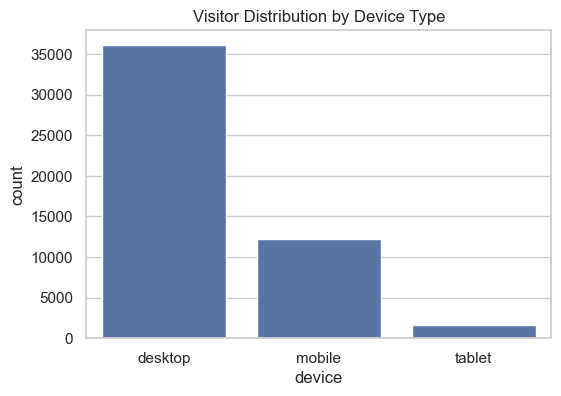

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='device', data=data)
plt.title("Visitor Distribution by Device Type")
plt.show()

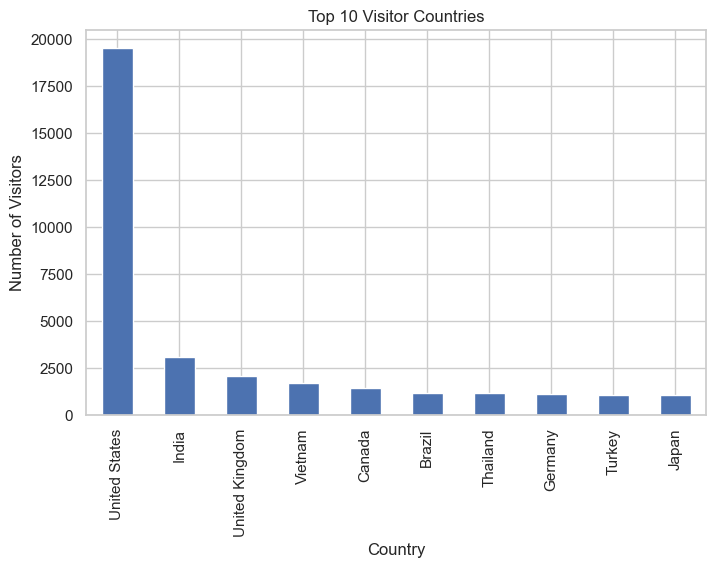

In [23]:
top_countries = data['country'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_countries.plot(kind='bar')
plt.title("Top 10 Visitor Countries")
plt.xlabel("Country")
plt.ylabel("Number of Visitors")
plt.show()

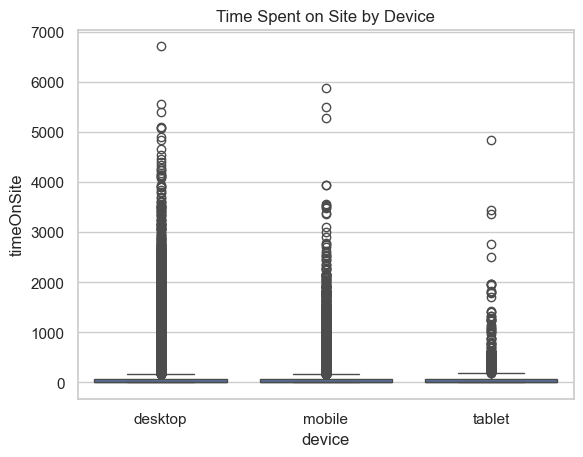

In [24]:
sns.boxplot(x='device', y='timeOnSite', data=data)
plt.title("Time Spent on Site by Device")
plt.show()

In [25]:
print(data.isnull().sum())

country       0
device        0
pageviews     0
bounces       0
timeOnSite    0
dtype: int64


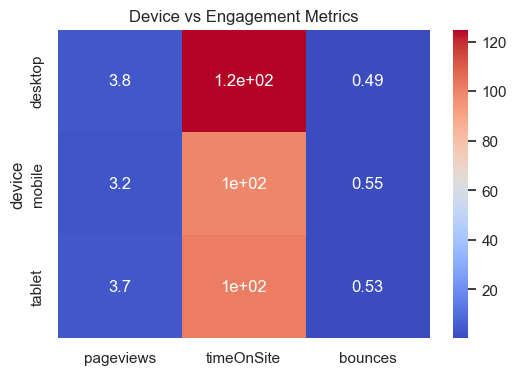

In [26]:
#device vs engagement heatmap
device_engagement = data.groupby('device')[['pageviews','timeOnSite','bounces']].mean()

plt.figure(figsize=(6,4))
sns.heatmap(device_engagement, annot=True, cmap='coolwarm')
plt.title("Device vs Engagement Metrics")
plt.show()

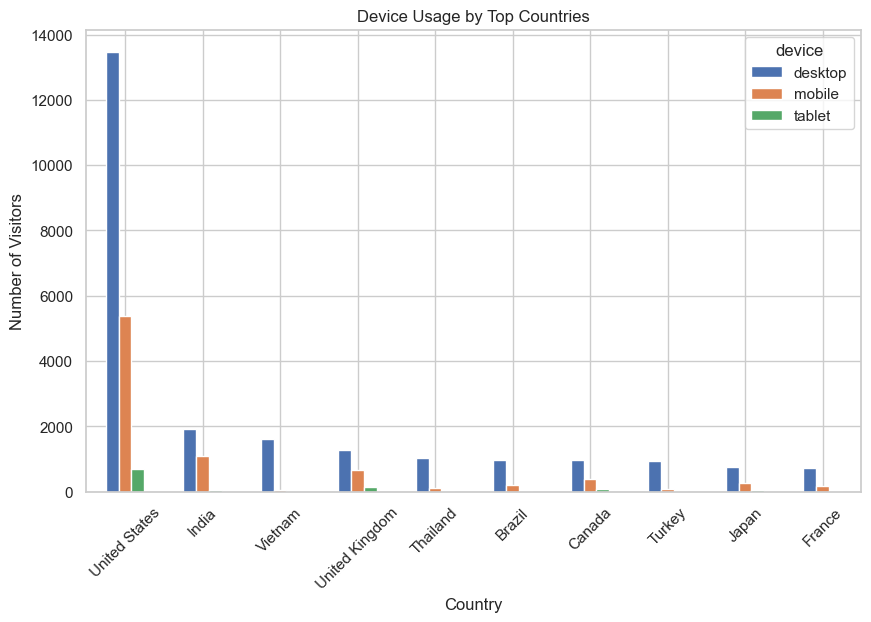

In [27]:
#country vs device distribution
country_device = pd.crosstab(data['country'], data['device'])

top_countries = country_device.sort_values(by='desktop', ascending=False).head(10)

top_countries.plot(kind='bar', figsize=(10,6))

plt.title("Device Usage by Top Countries")
plt.xlabel("Country")
plt.ylabel("Number of Visitors")
plt.xticks(rotation=45)
plt.show()

In [28]:
#Audience segmentation using clustering
from sklearn.cluster import KMeans

features = data[['pageviews','timeOnSite','bounces']]

kmeans = KMeans(n_clusters=3, random_state=42)

data['segment'] = kmeans.fit_predict(features)

In [29]:
data['segment'].value_counts()

segment
0    45926
2     3223
1      851
Name: count, dtype: int64

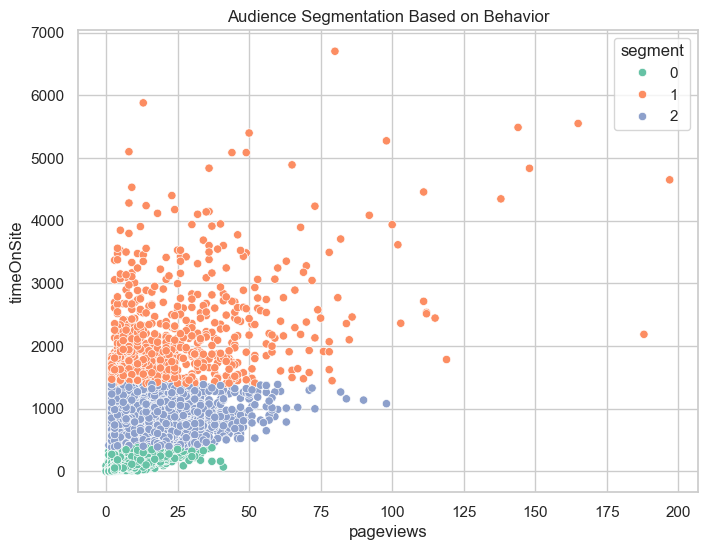

In [30]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='pageviews',
    y='timeOnSite',
    hue='segment',
    palette='Set2',
    data=data
)

plt.title("Audience Segmentation Based on Behavior")
plt.show()

In [31]:
data.groupby('segment')[['pageviews','timeOnSite','bounces']].mean()

,pageviews,timeOnSite,bounces
segment,,,
0,2.559465,39.529047,0.55302
1,21.949471,2076.245593,0.00000
2,14.064536,717.316475,0.00000
